In [29]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)

here = Path.cwd()
ROOT = here if (here / "data" / "processed").exists() else here.parent
PROCESSED = ROOT / "data" / "processed"

# load the analysis-ready data
df = gpd.read_file(PROCESSED / "yield_analysis_ready.gpkg")

# modeling set: drop flagged rows and any row with no yield target
model_df = df[(df["qc_flag"] == "") & (df["crop_yield"].notna())].copy()

print("analysis-ready rows:", len(df))
print("modeling rows (flagged removed, yield present):", len(model_df))
print()
print("rows per year:")
print(model_df["year"].value_counts().sort_index())
print()
print("target (crop_yield) summary:")
print(model_df["crop_yield"].describe().round(2).to_string())

analysis-ready rows: 1204
modeling rows (flagged removed, yield present): 1203

rows per year:
year
2022     55
2023     58
2024    323
2025    767
Name: count, dtype: int64

target (crop_yield) summary:
count    1203.00
mean        8.62
std         3.09
min         1.00
25%         7.00
50%         8.20
75%        10.00
max        47.00


yield summary (current modeling data, 1203 rows):
count    1203.00
mean        8.62
std         3.09
min         1.00
25%         7.00
50%         8.20
75%        10.00
max        47.00

skewness: 3.53  (0 = symmetric, >1 = right-tailed)


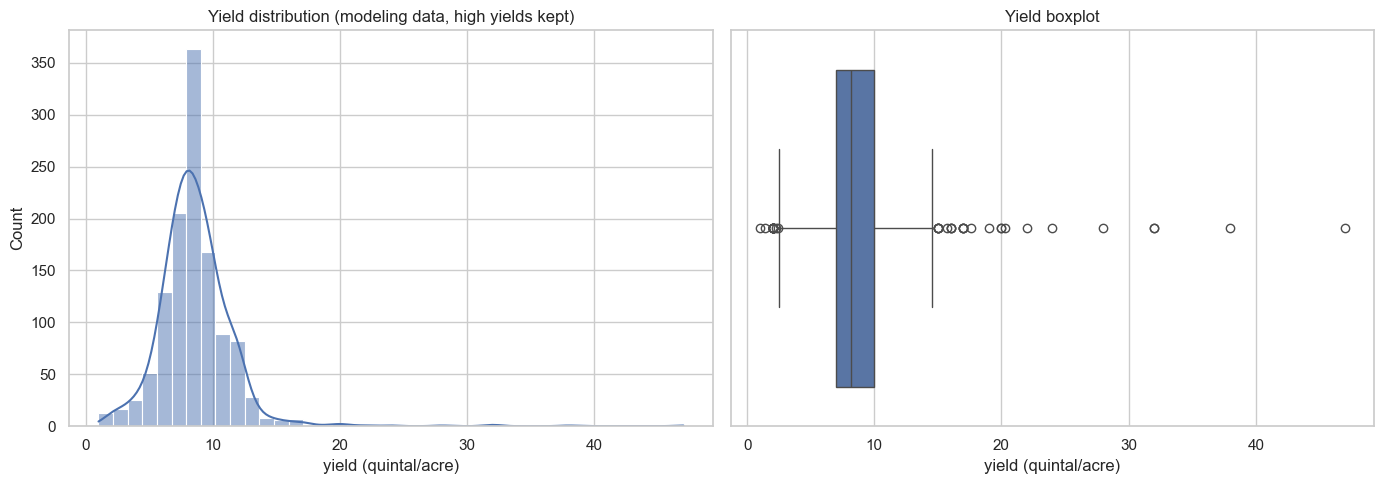

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

y = model_df["crop_yield"]

print("yield summary (current modeling data, 1203 rows):")
print(y.describe().round(2).to_string())
print()
print("skewness:", round(y.skew(), 2), " (0 = symmetric, >1 = right-tailed)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(y, bins=40, kde=True, ax=axes[0])
axes[0].set_title("Yield distribution (modeling data, high yields kept)")
axes[0].set_xlabel("yield (quintal/acre)")

sns.boxplot(x=y, ax=axes[1])
axes[1].set_title("Yield boxplot")
axes[1].set_xlabel("yield (quintal/acre)")

plt.tight_layout()
plt.show()

## Yield distribution (modeling data, high yields kept)

Re-checking the target distribution on the final modeling set (1203 rows), now that the 8 high yields have been kept.

The bulk of the data is still a hill centred around 8 quintal/acre, but keeping the high yields (up to 47) has added a long right tail. Skewness is now 3.53, which is strongly right-skewed (0 means symmetric, above 1 means a heavy right tail). The boxplot shows the tail clearly: a tight box around 7 to 10, then scattered points out to 47.

This matters for linear regression, which is sensitive to extreme values. A few points at 32 to 47 can pull the fitted line toward them and worsen predictions for the normal fields. The high yields are kept (that decision stands), so we handle the skew at the modelling stage instead: either predict log(yield) to compress the tail, or rely on tree-based models later that are robust to skew. This is noted here and applied in the modelling cells.

In [31]:
# ---- Choose features and target ----
target = "crop_yield"

# numeric features
num_features = ["area_acres", "year"]

# category features (text -> the model needs these encoded later)
cat_features = ["irrigation", "taluka", "variety",
                "soil_texture", "soil_depth", "soil_color", "soil_structure"]

features = num_features + cat_features

# the group column for the spatial split (not a feature, used to keep villages together)
group_col = "village"

# quick check: how many blanks in each feature (linear regression cannot handle blanks directly)
print("blanks in each feature:")
print(model_df[features].isna().sum().to_string())
print()
print("features:", features)
print("target:", target)
print("group (for split):", group_col)

blanks in each feature:
area_acres          0
year                0
irrigation          0
taluka              0
variety             0
soil_texture      226
soil_depth        226
soil_color        226
soil_structure    226

features: ['area_acres', 'year', 'irrigation', 'taluka', 'variety', 'soil_texture', 'soil_depth', 'soil_color', 'soil_structure']
target: crop_yield
group (for split): village


In [32]:
import numpy as np
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

# ---- 1. Fill blanks (leak-safe) ----
data = model_df.copy()
for c in cat_features:
    data[c] = data[c].astype(str).replace(["nan", "None", ""], "Unknown").fillna("Unknown")
for c in num_features:
    if data[c].isna().any():
        data[c] = data[c].fillna(data[c].median())

# ---- 2. Build spatial groups: cluster fields within 200 m ----
utm = data.to_crs(32643)
coords = np.c_[utm.geometry.centroid.x.values, utm.geometry.centroid.y.values]
tree = cKDTree(coords)
pairs = tree.query_pairs(r=200)
n = len(data)
r, c = [], []
for a, b in pairs:
    r += [a, b]; c += [b, a]
graph = csr_matrix((np.ones(len(r)), (r, c)), shape=(n, n))
_, geo_group = connected_components(graph, directed=False)
data["geo_group"] = geo_group
print("spatial groups:", data["geo_group"].nunique(), "from", len(data), "fields")

# ---- 3. Hold out a FINAL TEST set (15%), grouped. Touched only at the very end. ----
X = data[features]; y = data[target]; groups = data["geo_group"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
dev_idx, test_idx = next(gss.split(X, y, groups))

X_dev,  y_dev,  g_dev  = X.iloc[dev_idx],  y.iloc[dev_idx],  groups.iloc[dev_idx]
X_test, y_test         = X.iloc[test_idx], y.iloc[test_idx]

print(f"\ndevelopment set (for CV): {len(X_dev)} fields | held-out test: {len(X_test)} fields")

# ---- 4. Set up grouped 5-fold CV on the development set ----
N_FOLDS = 5
gkf = GroupKFold(n_splits=N_FOLDS)
print(f"\ngrouped {N_FOLDS}-fold CV ready on the development set.")
print("fold sizes (train / val fields per fold):")
for i, (tr, va) in enumerate(gkf.split(X_dev, y_dev, g_dev), 1):
    print(f"  fold {i}: train {len(tr)} | val {len(va)}")

# ---- 5. Confirm no spatial group leaks between dev and test ----
overlap = set(g_dev) & set(groups.iloc[test_idx])
print("\ngroups shared dev/test:", len(overlap), "(must be 0)")

spatial groups: 807 from 1203 fields

development set (for CV): 1010 fields | held-out test: 193 fields

grouped 5-fold CV ready on the development set.
fold sizes (train / val fields per fold):
  fold 1: train 808 | val 202
  fold 2: train 808 | val 202
  fold 3: train 808 | val 202
  fold 4: train 808 | val 202
  fold 5: train 808 | val 202

groups shared dev/test: 0 (must be 0)


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score

# categories -> 0/1 columns; numeric passed through
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ("num", "passthrough", num_features),
])

# scorers (RMSE, MAE, R2). sklearn maximizes, so error scores come back negative; we flip them.
scoring = {
    "rmse": make_scorer(lambda a, b: np.sqrt(mean_squared_error(a, b)), greater_is_better=False),
    "mae":  make_scorer(mean_absolute_error, greater_is_better=False),
    "r2":   make_scorer(r2_score),
}

def cv_evaluate(model, name):
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    res = cross_validate(pipe, X_dev, y_dev, groups=g_dev, cv=gkf, scoring=scoring)
    rmse = -res["test_rmse"]; mae = -res["test_mae"]; r2 = res["test_r2"]
    print(f"{name:<20} RMSE {rmse.mean():5.2f} +/- {rmse.std():.2f} | "
          f"MAE {mae.mean():5.2f} | R2 {r2.mean():6.3f} +/- {r2.std():.3f}")

print("Grouped 5-fold CV on development set (test held out)")
print("model                RMSE                 MAE       R2")
print("-" * 62)
cv_evaluate(DummyRegressor(strategy="mean"), "Dummy (mean)")
cv_evaluate(LinearRegression(), "Linear Regression")

Grouped 5-fold CV on development set (test held out)
model                RMSE                 MAE       R2
--------------------------------------------------------------
Dummy (mean)         RMSE  3.08 +/- 0.69 | MAE  2.00 | R2 -0.002 +/- 0.003
Linear Regression    RMSE  2.99 +/- 0.58 | MAE  1.95 | R2  0.041 +/- 0.054


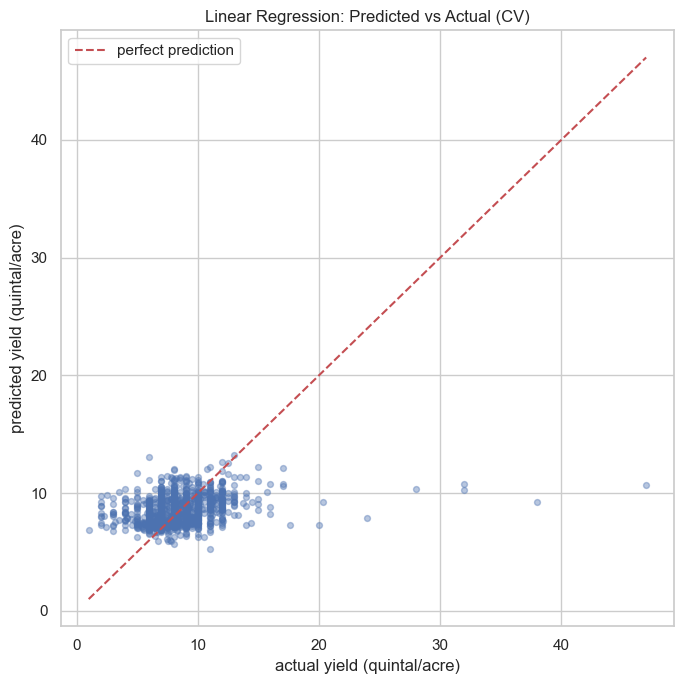

CV R2: 0.065


In [34]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict

lin_pipe = Pipeline([("prep", preprocess), ("model", LinearRegression())])

# cross-validated predictions (each field predicted when it was in its validation fold)
y_pred_cv = cross_val_predict(lin_pipe, X_dev, y_dev, groups=g_dev, cv=gkf)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_dev, y_pred_cv, alpha=0.4, s=18)
lims = [min(y_dev.min(), y_pred_cv.min()), max(y_dev.max(), y_pred_cv.max())]
ax.plot(lims, lims, "r--", label="perfect prediction")
ax.set_xlabel("actual yield (quintal/acre)")
ax.set_ylabel("predicted yield (quintal/acre)")
ax.set_title("Linear Regression: Predicted vs Actual (CV)")
ax.legend()
plt.tight_layout()
plt.show()

print("CV R2:", round(r2_score(y_dev, y_pred_cv), 3))

In [35]:
from sklearn.model_selection import cross_validate

lin_pipe = Pipeline([("prep", preprocess), ("model", LinearRegression())])

# return_train_score=True gives us BOTH train and validation scores per fold
res = cross_validate(
    lin_pipe, X_dev, y_dev, groups=g_dev, cv=gkf,
    scoring={"r2": make_scorer(r2_score),
             "rmse": make_scorer(lambda a, b: np.sqrt(mean_squared_error(a, b)),
                                 greater_is_better=False)},
    return_train_score=True,
)

train_r2 = res["train_r2"];  val_r2 = res["test_r2"]
train_rmse = -res["train_rmse"];  val_rmse = -res["test_rmse"]

print("Linear Regression: TRAIN vs VALIDATION (grouped 5-fold CV)")
print("-" * 50)
print(f"{'':12}{'R2':>10}{'RMSE':>10}")
print(f"{'TRAIN':12}{train_r2.mean():>10.3f}{train_rmse.mean():>10.2f}")
print(f"{'VALIDATION':12}{val_r2.mean():>10.3f}{val_rmse.mean():>10.2f}")
print("-" * 50)
print(f"gap (train R2 - val R2): {train_r2.mean() - val_r2.mean():.3f}")
print()
print("How to read:")
print("  both LOW and CLOSE      -> underfitting (weak features/model)")
print("  train HIGH, val LOW/gap -> overfitting (memorizing)")

Linear Regression: TRAIN vs VALIDATION (grouped 5-fold CV)
--------------------------------------------------
                    R2      RMSE
TRAIN            0.144      2.91
VALIDATION       0.041      2.99
--------------------------------------------------
gap (train R2 - val R2): 0.103

How to read:
  both LOW and CLOSE      -> underfitting (weak features/model)
  train HIGH, val LOW/gap -> overfitting (memorizing)


## Overfitting or underfitting? (train vs validation)

To diagnose the baseline, we compare the model's score on the training data against the validation data, using grouped 5-fold CV.

| | R2 | RMSE |
|---|---|---|
| Train | 0.144 | 2.91 |
| Validation | 0.041 | 2.99 |

Gap (train R2 minus validation R2): 0.103

**Verdict: underfitting.** Both scores are low, and the gap between them is small. This is the underfitting signature: the model is weak even on the data it trained on (train R2 only 0.144), so it is not memorizing. Overfitting would instead show a high train score and a large gap to a low validation score, which is not the case here.

**Important nuance:** the underfitting is driven by weak features, not a weak model. Linear regression reaches only R2 = 0.14 even when given the training answers, because the field attributes (irrigation, soil type, area, variety, location) carry very little yield signal, as EDA already indicated. The fix is therefore better features (satellite data), not a more complex model. A stronger model on these same features would be expected to raise the train score while validation stays near 0.04, which would confirm that the ceiling is set by the features.

**Baseline result:** validation R2 approximately 0.04, RMSE approximately 3.0 quintal/acre. This is the documented floor that satellite-derived features must improve upon.

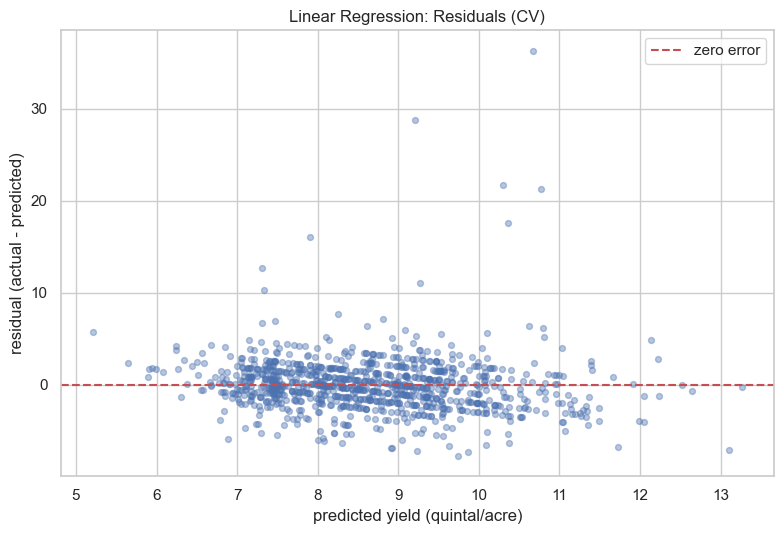

mean residual (should be near 0): -0.012
residual std: 3.046


In [36]:
resid = y_dev.values - y_pred_cv

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(y_pred_cv, resid, alpha=0.4, s=18)
ax.axhline(0, color="r", ls="--", label="zero error")
ax.set_xlabel("predicted yield (quintal/acre)")
ax.set_ylabel("residual (actual - predicted)")
ax.set_title("Linear Regression: Residuals (CV)")
ax.legend()
plt.tight_layout()
plt.show()

print("mean residual (should be near 0):", round(resid.mean(), 3))
print("residual std:", round(resid.std(), 3))

## Residual analysis

Residuals (actual minus predicted) plotted against predicted yield, from cross-validated predictions.

**Centered but weak.** The mean residual is -0.012 (essentially zero) and the main cloud sits evenly around the zero line, so the model is statistically unbiased: its average prediction is centered correctly, not systematically too high or too low.

**Fails on high yields.** The large residuals are almost all positive and belong to the high-yield fields (a field that yielded 47 was predicted near 10, giving a residual of +36). The model never predicts high, so every exceptional field produces a large positive error. This is the same "predicts near the mean" behaviour seen in the predicted-vs-actual plot, viewed from the error side.

**Residual spread** (std = 3.05) matches the RMSE, confirming a typical error of about 3 quintal/acre against a mean yield of 8.6. The driver is weak features, addressed by satellite data rather than a different model.

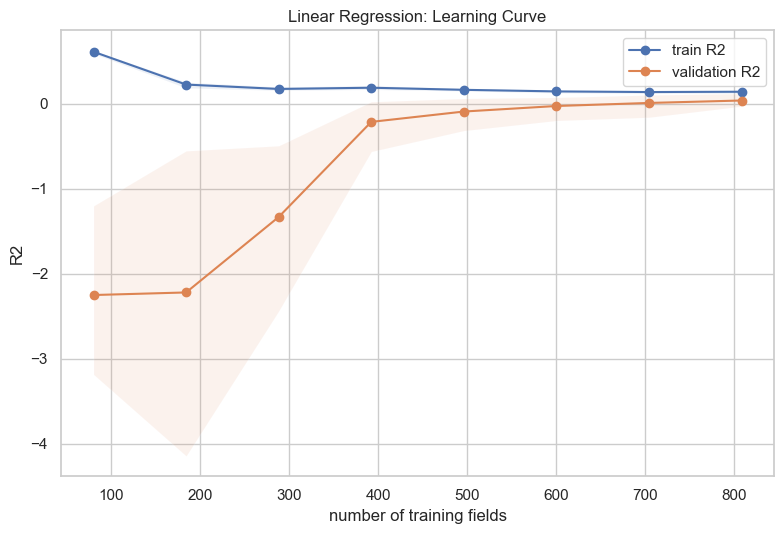

final train R2: 0.144 | final validation R2: 0.041


In [37]:
from sklearn.model_selection import learning_curve

lin_pipe = Pipeline([("prep", preprocess), ("model", LinearRegression())])

sizes, train_scores, val_scores = learning_curve(
    lin_pipe, X_dev, y_dev, groups=g_dev, cv=gkf,
    train_sizes=np.linspace(0.1, 1.0, 8), scoring="r2")

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(sizes, train_mean, "o-", label="train R2")
ax.plot(sizes, val_mean, "o-", label="validation R2")
ax.fill_between(sizes, train_scores.min(axis=1), train_scores.max(axis=1), alpha=0.1)
ax.fill_between(sizes, val_scores.min(axis=1), val_scores.max(axis=1), alpha=0.1)
ax.set_xlabel("number of training fields")
ax.set_ylabel("R2")
ax.set_title("Linear Regression: Learning Curve")
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "06_linreg_learning_curve.png", dpi=120)
plt.show()

print("final train R2:", round(train_mean[-1], 3), "| final validation R2:", round(val_mean[-1], 3))

## Learning curve (does more data help?)

Model R2 as a function of training set size, for both train and validation, using grouped 5-fold CV.

**Both curves converge low.** At the full training size (~800 fields), train R2 settles around 0.14 and validation R2 rises to about 0.04. The two lines meet at a low value, which is the classic underfitting signature: the model has reached its ceiling, and that ceiling is low.

**Reading left to right.** With very few fields (~80) the validation R2 is strongly negative (about -2.2) and highly unstable (wide band across folds), which is expected for tiny, grouped training sets. As training data grows, validation improves quickly through the 200 to 400 range, then flattens from about 500 fields onward.

**Does more data help? No.** The validation curve has plateaued at the right side, it is flat, not still rising. This means collecting more fields will not improve this model. The limit is set by the features, not the amount of data.

**Conclusion.** The learning curve rules out the two alternative explanations: it is not overfitting (the train and validation lines converge with a small gap), and it is not a data-quantity problem (validation plateaus). The low ceiling is caused by weak features. The path to improvement is better inputs, specifically satellite-derived features (SAR and optical), rather than more rows or a more complex model on the same attributes.

In [38]:
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline

# RFE needs numeric input, so encode first, then select, then linear regression.
# We build the encoded matrix once and run RFECV on it (with grouped CV).
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

encoder = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ("num", "passthrough", num_features),
])

X_enc = encoder.fit_transform(X_dev)
if hasattr(X_enc, "toarray"):
    X_enc = X_enc.toarray()
enc_names = encoder.get_feature_names_out()
print("encoded columns:", X_enc.shape[1])

# RFECV: recursively remove weakest columns, pick the number that maximizes CV R2
rfe = RFECV(
    estimator=LinearRegression(),
    step=1,
    cv=gkf.split(X_enc, y_dev, g_dev),
    scoring="r2",
    min_features_to_select=1,
)
rfe.fit(X_enc, y_dev)

print("optimal number of encoded columns:", rfe.n_features_)
print("best CV R2 with those columns:", round(rfe.cv_results_["mean_test_score"].max(), 4))
print()

# which columns survived, grouped back to raw features
kept = enc_names[rfe.support_]
print("kept columns (", len(kept), "):")
for k in kept:
    print("  ", k)

encoded columns: 50
optimal number of encoded columns: 18
best CV R2 with those columns: 0.0559

kept columns ( 18 ):
   cat__irrigation_Flow/Protective
   cat__irrigation_Rainfed
   cat__taluka_Deoni
   cat__taluka_Jalkot
   cat__taluka_Latur
   cat__taluka_Renapur
   cat__variety_KDS 726
   cat__variety_KDS 753
   cat__variety_MAUS 162
   cat__variety_MAUS 71
   cat__soil_depth_Shallow
   cat__soil_color_Red
   cat__soil_color_Unknown
   cat__soil_color_White
   cat__soil_structure_Coarse
   cat__soil_structure_Fine
   cat__soil_structure_Medium
   cat__soil_structure_Very Fine


## Recursive feature elimination (does trimming features help?)

Tested whether removing weak features improves the baseline, using RFECV (recursive feature elimination with grouped 5-fold CV) on the one-hot encoded features, re-fitting linear regression at each step.

**Result: no meaningful improvement.** RFE reduced the 50 encoded columns to an optimal 18, and the best CV R2 rose only from 0.041 to 0.056. Explaining 5.6% of yield instead of 4% is still negligible. This confirms the ceiling is set by weak features, not by having too many of them, removing columns cannot add signal that was never present.

**What survived is informative.** The 18 retained columns identify the features that carry the little signal that exists, consistent with EDA:
- Irrigation (Flow/Protective, Rainfed) - the strongest attribute.
- A few varieties (KDS 753, KDS 726, MAUS 71, MAUS 162) - variety carries some signal, which justified standardising it.
- Some talukas (Latur, Renapur, Deoni, Jalkot) - weak location effect.
- Some soil description categories (color, structure, depth).

**What was dropped is also telling.** year, area_acres, and most soil texture columns did not survive, so they contribute almost nothing to predicting yield on their own.

**Conclusion.** Even the optimal subset of field attributes explains under 6% of yield variation. This rules out model over-complexity as the cause of the weak baseline and reinforces that the limitation is the information content of the features. Satellite-derived features remain the path to improvement.

In [39]:
# ---- Feature strength vs yield (right method per feature type) ----
# numeric -> |correlation|. category -> correlation ratio (eta): how much category explains yield.

def correlation_ratio(categories, values):
    # eta: fraction of yield variance explained by the category groups
    cats = pd.Series(categories).astype(str)
    vals = pd.Series(values).values
    grand_mean = vals.mean()
    ss_total = ((vals - grand_mean) ** 2).sum()
    ss_between = 0.0
    for c in cats.unique():
        grp = vals[cats.values == c]
        ss_between += len(grp) * (grp.mean() - grand_mean) ** 2
    return np.sqrt(ss_between / ss_total) if ss_total > 0 else 0.0

y = data[target]

rows = []
for c in num_features:
    corr = abs(data[c].corr(y))
    rows.append({"feature": c, "type": "numeric", "strength": round(corr, 3)})
for c in cat_features:
    eta = correlation_ratio(data[c], y)
    rows.append({"feature": c, "type": "category", "strength": round(eta, 3)})

strength = pd.DataFrame(rows).sort_values("strength", ascending=False)
print("Feature strength vs yield (higher = stronger relation):")
print(strength.to_string(index=False))

Feature strength vs yield (higher = stronger relation):
       feature     type  strength
    soil_color category     0.253
  soil_texture category     0.253
soil_structure category     0.243
    soil_depth category     0.234
       variety category     0.221
    irrigation category     0.197
          year  numeric     0.146
        taluka category     0.096
    area_acres  numeric     0.002


## Feature strength vs yield (cross-check against RFE)

Measured how strongly each feature relates to yield, using the correct method per type: absolute correlation for numeric features (area, year), and the correlation ratio (eta, 0 to 1) for category features.

**Agreements with RFE.** area_acres is effectively useless (0.002), which matches RFE dropping it entirely. Variety and irrigation both carry real (if weak) signal in both analyses.

**Disagreement, and why.** Here soil description ranks highest (~0.25), but RFE treated irrigation and variety as more useful. The reason is that eta measures in-sample association (do groups differ in yield?), while RFE measures out-of-fold predictive power (does the feature help predict new fields?). Eta can be inflated by categories with many or small subgroups, for example the soil_color "White" group had a high mean yield but very few fields. So soil description is associated with yield but not strongly predictive. For deciding what actually helps prediction, the cross-validated RFE result is more reliable.

**Combined conclusion.** area_acres is dead; variety and irrigation are the most useful attributes; soil description is associated but weakly predictive; taluka and year are weak. Critically, even the highest strength is only ~0.25 and likely overstated, so no field attribute is a strong predictor. This reinforces the need for satellite-derived features.

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE

# base Random Forest (conservative default settings)
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)

def cv_train_val(pipe, name):
    res = cross_validate(
        pipe, X_dev, y_dev, groups=g_dev, cv=gkf,
        scoring={"r2": make_scorer(r2_score),
                 "rmse": make_scorer(lambda a, b: np.sqrt(mean_squared_error(a, b)),
                                     greater_is_better=False)},
        return_train_score=True,
    )
    tr_r2 = res["train_r2"].mean(); va_r2 = res["test_r2"].mean()
    tr_rm = -res["train_rmse"].mean(); va_rm = -res["test_rmse"].mean()
    print(f"{name}")
    print(f"   TRAIN  R2 {tr_r2:6.3f} | RMSE {tr_rm:5.2f}")
    print(f"   VALID  R2 {va_r2:6.3f} | RMSE {va_rm:5.2f}")
    print(f"   gap (train-val R2): {tr_r2 - va_r2:.3f}")
    print()

# 1. Random Forest with ALL features
rf_all = Pipeline([("prep", preprocess), ("model", rf)])
cv_train_val(rf_all, "Random Forest (all features)")

# 2. Random Forest with RFE selecting the best ~18 encoded columns
rf_rfe = Pipeline([
    ("prep", preprocess),
    ("rfe", RFE(estimator=RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
                n_features_to_select=18)),
    ("model", rf),
])
cv_train_val(rf_rfe, "Random Forest (RFE, 18 features)")

Random Forest (all features)
   TRAIN  R2  0.879 | RMSE  1.09
   VALID  R2 -0.016 | RMSE  3.07
   gap (train-val R2): 0.895

Random Forest (RFE, 18 features)
   TRAIN  R2  0.880 | RMSE  1.09
   VALID  R2 -0.033 | RMSE  3.10
   gap (train-val R2): 0.913



## Random Forest baseline (with and without RFE)

Tested a non-linear model to check whether the weak linear baseline was due to model simplicity. Random Forest (300 trees) run through grouped 5-fold CV, both with all features and with RFE-selected features, reporting train and validation scores.

**Severe overfitting.** Random Forest nearly memorises the training data (train R2 ~0.88) but fails completely on new fields (validation R2 ~0, slightly worse than predicting the mean). The huge train-validation gap (~0.90) shows it is fitting patterns that exist only in the training fields by chance, not genuine yield drivers. Feature selection via RFE does not help, the same overfitting persists.

**The definitive conclusion.** The two model extremes now agree on the validation set: linear regression underfits (train and validation both ~0.04) and Random Forest overfits (train 0.88, validation ~0), yet both reach essentially zero predictive power on unseen fields. When a simple model and a powerful model both fail to generalise, and the powerful one succeeds only by memorising, the limitation is the information content of the features, not the model. No model can predict signal that is not present in the inputs.

**Implication.** Field attributes (irrigation, soil description, variety, area, location) cannot predict soybean yield. This is not a model-selection problem or a data-quantity problem (the learning curve had already plateaued). Satellite-derived features (SAR and optical), which capture the actual crop condition through the season, are the necessary next step.

In [42]:
from catboost import CatBoostRegressor, Pool

# use the SAME development rows as the other models
Xc = X_dev.copy()
for c in cat_features:
    Xc[c] = Xc[c].astype(str).fillna("Unknown")
cat_idx = [Xc.columns.get_loc(c) for c in cat_features]

# manual grouped CV loop (avoids the sklearn-clone issue with CatBoost cat_features)
tr_r2s, va_r2s, tr_rms, va_rms = [], [], [], []

for tr, va in gkf.split(Xc, y_dev, g_dev):
    X_tr, X_va = Xc.iloc[tr], Xc.iloc[va]
    y_tr, y_va = y_dev.iloc[tr], y_dev.iloc[va]

    model = CatBoostRegressor(
        iterations=400, depth=6, learning_rate=0.05,
        random_state=42, verbose=0,
    )
    model.fit(Pool(X_tr, y_tr, cat_features=cat_idx))

    p_tr = model.predict(X_tr)
    p_va = model.predict(X_va)

    tr_r2s.append(r2_score(y_tr, p_tr))
    va_r2s.append(r2_score(y_va, p_va))
    tr_rms.append(np.sqrt(mean_squared_error(y_tr, p_tr)))
    va_rms.append(np.sqrt(mean_squared_error(y_va, p_va)))

print("CatBoost (native categories)")
print(f"   TRAIN  R2 {np.mean(tr_r2s):6.3f} | RMSE {np.mean(tr_rms):5.2f}")
print(f"   VALID  R2 {np.mean(va_r2s):6.3f} | RMSE {np.mean(va_rms):5.2f}")
print(f"   gap (train-val R2): {np.mean(tr_r2s) - np.mean(va_r2s):.3f}")

CatBoost (native categories)
   TRAIN  R2  0.402 | RMSE  2.42
   VALID  R2  0.069 | RMSE  2.95
   gap (train-val R2): 0.333


## Baseline model comparison (linear, Random Forest, CatBoost)

Three models spanning simple to complex, all run through the same grouped 5-fold CV on the development set, reporting train and validation R2.

| Model | Train R2 | Valid R2 | Gap | Behaviour |
|-------|----------|----------|-----|-----------|
| Linear Regression | 0.144 | 0.041 | 0.10 | Underfits |
| Random Forest (300 trees) | 0.879 | -0.016 | 0.90 | Overfits badly |
| CatBoost | 0.402 | 0.069 | 0.33 | Best balance |

**Reading the table.** Linear regression underfits: both scores are low and close, it is too weak to fit even the training data. Random Forest overfits severely: it nearly memorises the training set (0.88) but fails on new fields (~0), with a huge gap. CatBoost strikes the best balance, its native categorical handling extracts a little more signal (validation 0.069) while overfitting far less than Random Forest (gap 0.33 vs 0.90).

**The key conclusion.** The best validation score any model achieves is R2 = 0.069 (CatBoost), meaning field attributes explain at most about 7% of yield variation. This spans the full range of model complexity: a linear model, a bagging ensemble, and a gradient boosting model tuned for categorical data. When the model best suited to this data type still hits a ceiling near 7%, the limitation is clearly the information in the features, not the choice of model.

**Implication.** The remaining ~93% of yield variation is driven by factors absent from the ground-truth file, chiefly in-season weather and crop condition. These can only be captured through satellite-derived features (SAR and optical), which is the next stage. The baseline to beat is R2 approximately 0.07, RMSE approximately 3.0 quintal/acre.